# 1. Import our in-house package and dependencies
Should install relevant dependencies if there is a conflict

In [1]:
import RoPeR
from RoPeR import bandpass, bgr, energy_eq, gain, prestitch
import SimulatingGPR.gprsim as gprsim

In [2]:
import os
from tqdm import tqdm
from pds4_tools.reader.core import pds4_read
import numpy as np
import matplotlib.pyplot as plt

# 2. Load the RoPeR data from a folder on our computer which contains the data files

In [3]:
'''
Retrieving files and sorting them
'''
n, m = 0, 109 # 0-109, load all 109 files
data_dir = '/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_LF' # were data

In [4]:
files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if '.2CL' in f]
files = sorted(files, key=lambda f: int(f[-10:-6]))[n:m]
length = len(files)

sample_depth = {6000:15000, 4000:10000, 2000:5000, 1000:2500} # number of total pixels in either R/I data: nanoseconds penetration
observable_depth_ns = 1200 # Arbitaraty value

In [5]:
from collections import Counter, defaultdict
'''
Check inhomogenous data (e.g. not all files are LF). also get the effective data legnth (to get ns/px)
'''

effective_data_lens = [info[8] for info in [pds4_read(file, quiet=True)[0].data[0] for file in files]] # Just take the metadata associated with the first trace, as each trace in each file will be the same


if len(set(effective_data_lens)) == 1:
    print(f"Input data is homogenous. Effective data length is {effective_data_lens[0]} bytes. \n {effective_data_lens[0]/8} fpn for real data -- {(effective_data_lens[0]/8)/sample_depth[effective_data_lens[0]/8]} px/ns")
    half_length = int(effective_data_lens[0]/8)
    px_per_ns = half_length/sample_depth[effective_data_lens[0]/8]
else:
    print("Inhomogenous data types. Check that all files are LF or have the same effective data length")

Input data is homogenous. Effective data length is 48000 bytes. 
 6000.0 fpn for real data -- 0.4 px/ns


In [6]:
remove_air = 0

In [7]:
'''
Stitching multiple data files together and gathering some preprocessing data for each file
'''
phase = [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
pixel_distances = []
sample_meta = None
for f, i, j in zip(files, range(0, length), tqdm(range(length-1))): 
    if n<=i<=m:
        fdata = pds4_read(f, quiet=True)[0].data
        if len(set([int.from_bytes(d[6], 'big', signed=False) for d in fdata])) > 1:
            raise Exception("Trigger mode is not homogenously fixed_distance")
        sample_meta = fdata[0] # might be useless
        scan2d = np.array([d[9] for d in fdata])
        real_part_scan2d = np.array(scan2d[:, :half_length]).T[remove_air:, :]
        
        sample_depth_px, real_part_scan2d_depth_adj = prestitch.depth_correction(real_part_scan2d, px_per_ns, observable_depth_ns)
        real_part_scan2d_depth_self_adj, sds = prestitch.remove_self_detection(real_part_scan2d_depth_adj)
        sds = prestitch.phase_correction(sds, phase[i])
        real_part_scan2d_depth_self_phase_adj = prestitch.phase_correction(real_part_scan2d_depth_self_adj, phase[i])
        real_part_scan2d_depth_self_phase_bgr_adj, _ = bgr.remove_bg(real_part_scan2d_depth_self_phase_adj)
        # Assume this is all interpreted
        yaw = np.array([d[23] for d in fdata])
        pos_x = np.array([d[19] for d in fdata])
        pos_y = np.array([d[20] for d in fdata])
        pos_z = np.array([d[21] for d in fdata])
        pixel_distances.append(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
        if i == n:
            raw = real_part_scan2d_depth_adj
            self_detection = real_part_scan2d_depth_self_adj
            phase_offset = real_part_scan2d_depth_self_phase_adj
            phase_offset_bg = real_part_scan2d_depth_self_phase_bgr_adj
            self_detections = np.array(sds)
            yaws = yaw
            poss_x, poss_y, poss_z = pos_x, pos_y, pos_z
            trace_dist_m = np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3) # Fixed dist trigger is not fixed for all scans, record dist in a way that pulls from the .CL
        else:
            raw = np.concatenate((raw, real_part_scan2d_depth_adj), axis=1)
            self_detection = np.concatenate((self_detection, real_part_scan2d_depth_self_adj), axis=1)
            phase_offset = np.concatenate((phase_offset, real_part_scan2d_depth_self_phase_adj), axis=1)
            phase_offset_bg = np.concatenate((phase_offset_bg, real_part_scan2d_depth_self_phase_bgr_adj), axis=1)
            self_detections = np.concatenate((self_detections, sds), axis=1)
            yaws = np.concatenate((yaws, yaw))
            poss_x, poss_y, poss_z = np.concatenate((poss_x, pos_x)), np.concatenate((poss_y, pos_y)), np.concatenate((poss_z, pos_z))
            trace_dist_m+=np.sum(np.array([int.from_bytes(d[7], 'big', signed=False) for d in fdata])*10e-3)
            

100%|████████████████████████████████████████████████████████████████████████| 107/107 [00:14<00:00,  7.15it/s]


(<matplotlib.image.AxesImage at 0x134b4bd60>,
 Text(0, 0.5, 'Two-way Travel time [ns]'),
 Text(0.5, 0, 'Trace Index'))

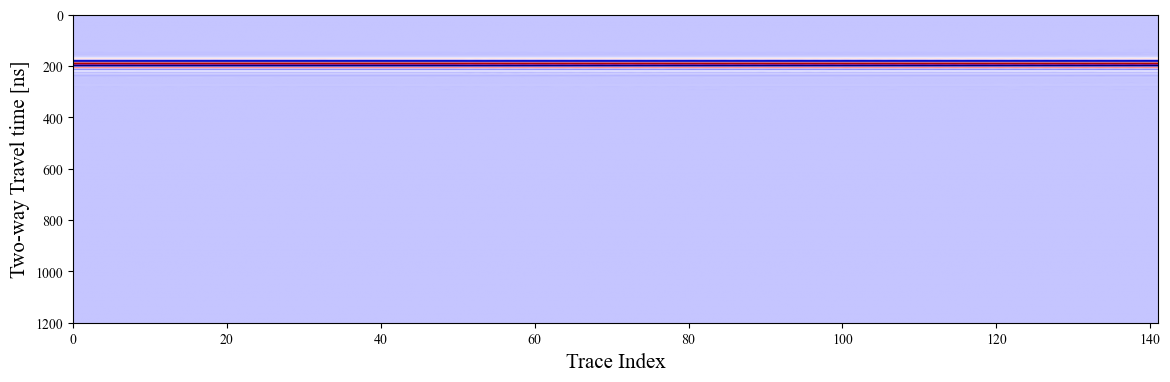

In [23]:
plt.imshow(self_detections, aspect='auto', cmap='seismic', extent = [0, self_detections.shape[1], observable_depth_ns, 0]), plt.ylabel('Two-way Travel time [ns]'), plt.xlabel('Trace Index')


## 2.1 Now we have all the data: But one problem?
Its up to us to manipulate it so that it is satisfactory. First, we want homogenous dx and dt. Right now dt is easy, given by 1/px_per_ns -- we'd know somethings up with this if the check for inhomogenous data failed (it shouldn't have). Dx is a little more complicated as the fixed distance trigger for the LF data switches to dx = 0.25 right before 2000 pixels. See:

Boundary pixel where dx starts being 0.25 is 1739


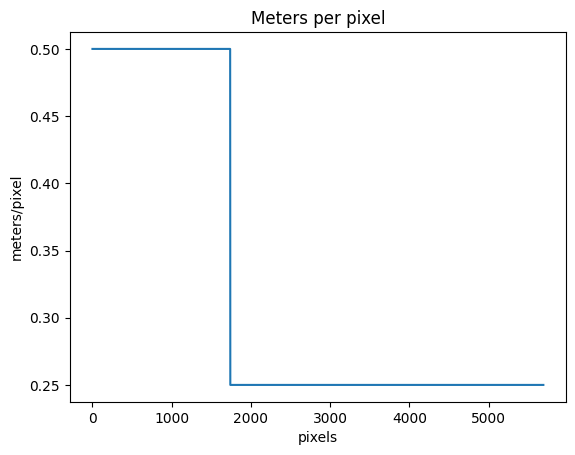

In [8]:
plt.plot(np.concatenate(pixel_distances).ravel())
plt.title("Meters per pixel")
plt.xlabel("pixels")
plt.ylabel("meters/pixel")
print('Boundary pixel where dx starts being 0.25 is', [i for i, val in enumerate(np.concatenate(pixel_distances).ravel()) if val==0.25][0])

### We have a couple options for dealing with this
1. Use cv2.resize: This would be visually appealing, yes, but I'm veto-ing it becasue we cant just create artificual data.
2. Give myself a migrane adjusting all of the velocity modeling code to use the pixel distrances array in all calculations: essentially treat dx as variable: doable, but overkill. Something simple is ideal here.
3. **Split the raw B-scan in two and just do everything past pre-processing separately**, then after imaging splice the tow back together. Fewer headaches, just hope there are no hyperbolae on the boundary. Eh, we should have enough as is. This solution doesn't create data for leave any out. Sure there may be a visible boundary in the final image, but I'll take this over disingenuous cv2.resize any day

# 3 Take a look at this initial data

## 3.1 Load a couple functions that make manipulating the data easier

**meters_to_pixels**: 
    
    takes a range along the horizontal and transforms it into pixel indices. this is useful as the RoPeR fixed distance trigger has multiple fixed distances under which it operates, for LF, this switches from 1 recording every 0.5m to everyu 0.25m

**norm2d**:

    Normalizes a 2d array to 0-1

**zoom**:

    Takes a slice of the full data. Useful for hyperbola tracing in velocity modeling, to check data quality, or to simply zoom in on features of the data



In [9]:
def meters_to_pixels(meter_interval, pixel_distances):
    start_m, end_m = meter_interval

    # cumulative distance to the start of each pixel
    cumulative_m = np.concatenate(([0], np.cumsum(pixel_distances)))

    # find pixel indices
    start_pixel = np.searchsorted(cumulative_m, start_m, side="left")
    end_pixel = np.searchsorted(cumulative_m, end_m, side="right") - 1

    # clamp to valid range
    start_pixel = max(0, min(start_pixel, len(pixel_distances) - 1))
    end_pixel = max(0, min(end_pixel, len(pixel_distances) - 1))

    return start_pixel, end_pixel
    
def norm2d(array):
    min_val = np.min(array)
    max_val = np.max(array)
    
    # Apply the normalization formula
    normalized_array = 2 * ((array - min_val) / (max_val - min_val)) - 1
    
    return normalized_array

def zoom(array, bounds):
    # Bounds in [left, right, bottom, top]
    # [:, :], Col slice (vertical), rows slice (horiz), row slice should be left:right, byut col slice should be bottom:top
    '''
    Bounds should be specified as:

                Left: Left coordinate (in meters)
                Right: Right coord (in meters)
                Top: stratigraphic bottom, the larger twt (in ns)
                Bottom: stratigraphic top, the smaller twt (in ns)

    This way bounds may be passed as an arg to plt without modification to show true (phyiscal) position 
    '''
    left, right = meters_to_pixels((bounds[0], bounds[1]), np.concatenate(pixel_distances).ravel())
    return array[int(bounds[3]*px_per_ns):int(bounds[2]*px_per_ns), left:right], bounds
    

## 3.2 View the raw data input

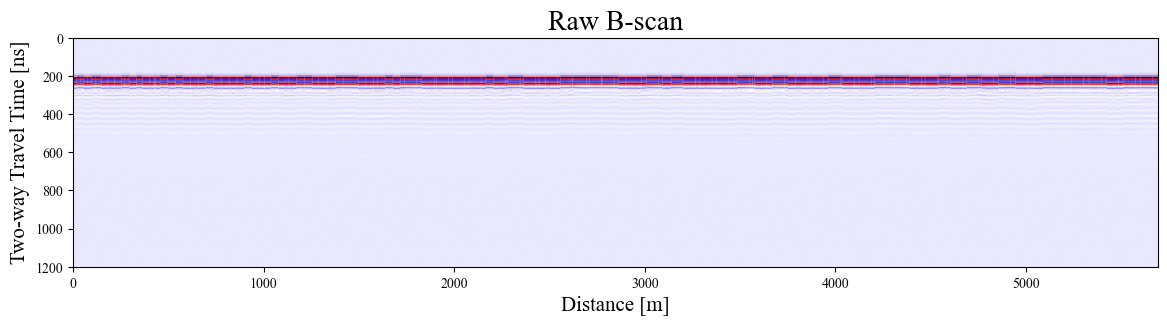

In [10]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 15,
    'axes.titlesize': 20,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.4,  # Example: Increase vertical spacing
    'figure.figsize': (14, 4) # Adjust figure size
})
rows, cols = raw.shape
plt.imshow(raw, cmap='seismic', extent = [0, cols, observable_depth_ns, 0])
plt.title("Raw B-scan")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/raw.png', raw, cmap='seismic')

## 3.3 Remove the self detection traces

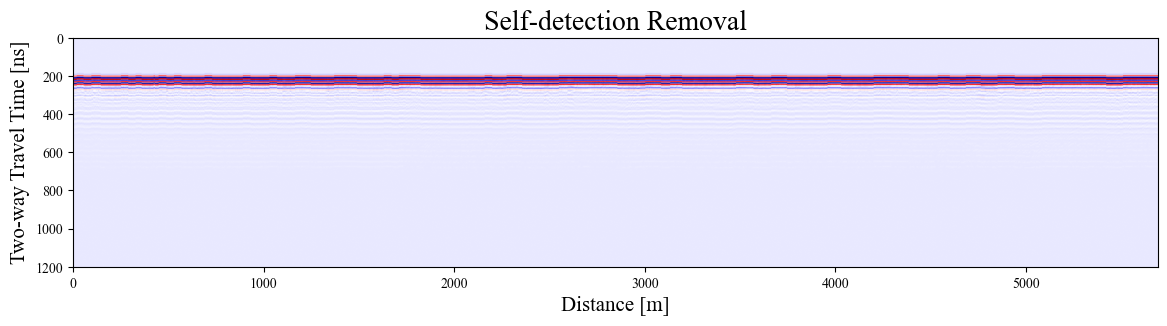

In [11]:
plt.imshow(self_detection, cmap='seismic',extent = [0, cols, observable_depth_ns, 0])
plt.title("Self-detection Removal")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/self_detection.png', self_detection, cmap='seismic')

## 3.4 Align the traces with the ground

27128466.0 -24998366.0


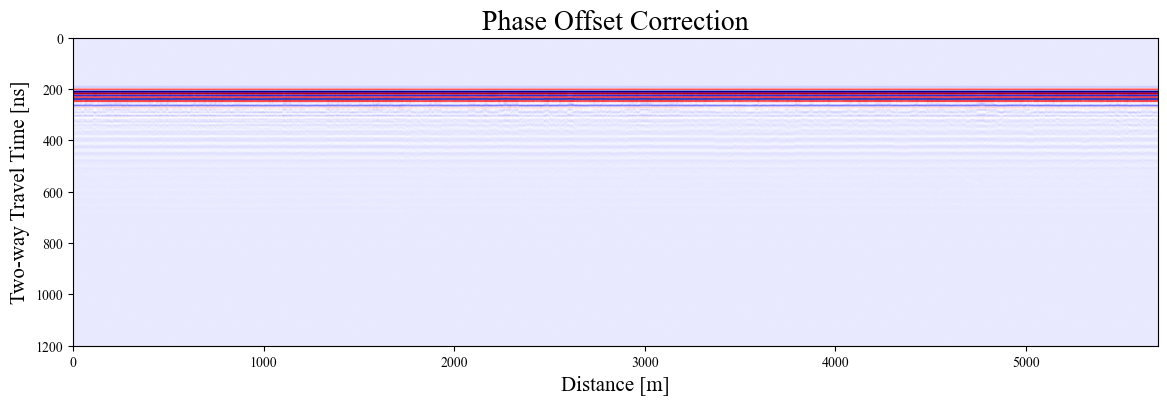

In [12]:
plt.imshow(phase_offset, cmap='seismic', aspect='auto', extent = [0, cols, observable_depth_ns, 0])
plt.title("Phase Offset Correction")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
print(np.amax(phase_offset), np.amin(phase_offset))
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/phase_offset.png', phase_offset, cmap='seismic')

### Characterizing the wavelet from B-scan

In [13]:
# HOw to get source from what we have?
# - Bandwidth?
# - try FT on all traces and plotting avg ft to get (how certain are we that this is the Spectral density distrib)

# 4. Signal processing
I'll just go at this in the order it's explained in the text. It's important to remind myself that the point here is not to reveal things that arent there, it's to 'clean' the noise away to see best what the refections look like. Sure if we do bgr removal 1000 times or throw a super long pipeline at this data we'll start seeing some funky stuff. I'd like to keep this pre-migration processing as simple as possible within reason. Indeed this isnt all the steps previously taken for the HF data, but I think what's important is that I've not only explained what's going on in each of these steps in my paper, but exactly ****

## 4.1 Remove horizontal Banding

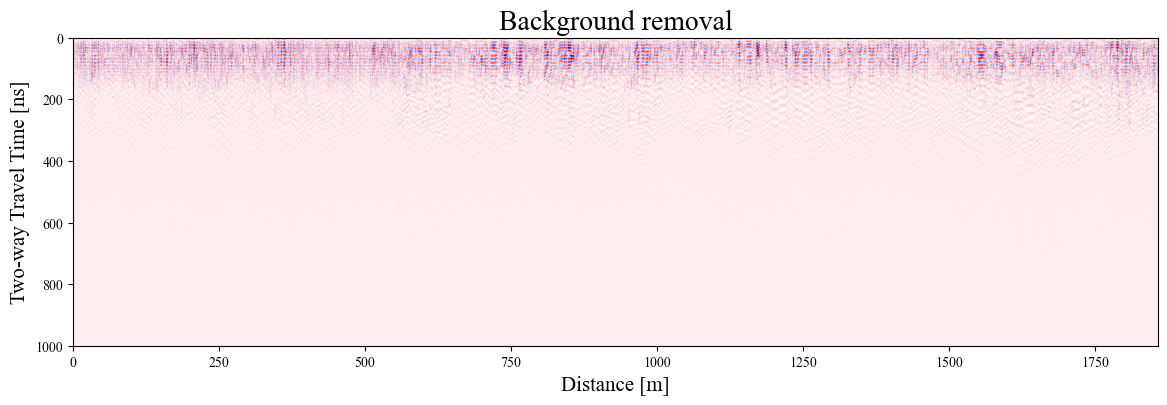

In [14]:
array = phase_offset_bg[int(200*px_per_ns):, :]# adjust time-lag
plt.imshow(array, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*array.shape[0], 0])
plt.title("Background removal")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/bgr.png', array, cmap='seismic')

## 4.1.1 Personal Prefernce Fix: Trace-to-trace coupling due to uneven surface

In [98]:
# Striping is most apparent in the upper 200ns
import numpy as np
from scipy.ndimage import uniform_filter1d

def trace_balance_rms(D, tmin, tmax, smooth_traces, eps):
    """
    D: (nt, nx) float radargram
    tmin/tmax: sample window used to estimate trace energy
    smooth_traces: smoothing length along x
    """
    nt, nx = D.shape
    if tmax is None:
        tmax = int(1 * nt)  # top 20% by default

    W = D[tmin:tmax, :]
    rms = np.sqrt(np.mean(W**2, axis=0) + eps)

    # smooth lateral gain curve
    rms_s = uniform_filter1d(rms, size=smooth_traces, mode='nearest')

    # scale each trace to match median energy
    target = np.median(rms_s)
    gain = target / (rms_s + eps)

    return D * gain[None, :], gain

array, gain = trace_balance_rms(array, tmin=0, tmax=None, smooth_traces=2, eps=100)


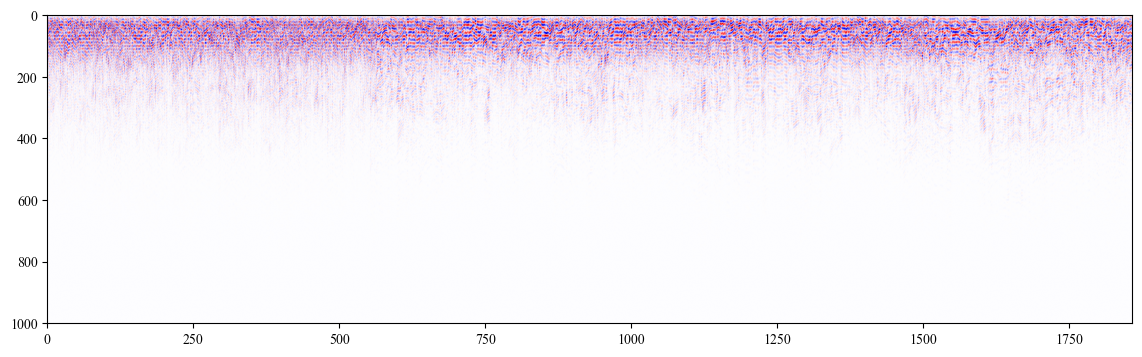

In [99]:
plt.imshow(array, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*array.shape[0], 0])
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/destripe.png', array, cmap='seismic')

## 4.2 Lateral energy equalization

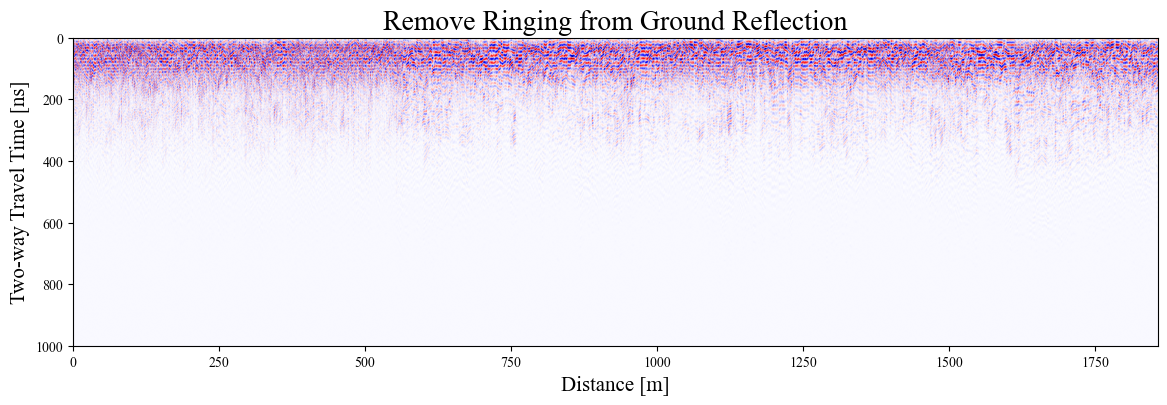

In [100]:
arr = energy_eq.lateral_energy_equalization(array, 10)
plt.imshow(arr, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*arr.shape[0], 0])
plt.title("Remove Ringing from Ground Reflection")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/lee.png', arr, cmap='seismic')

## 4.3 Bandpass filter

3.4 shows that the signal is pretty consistent across the data, this step shouldn't do much, but it also shouldn't hurt


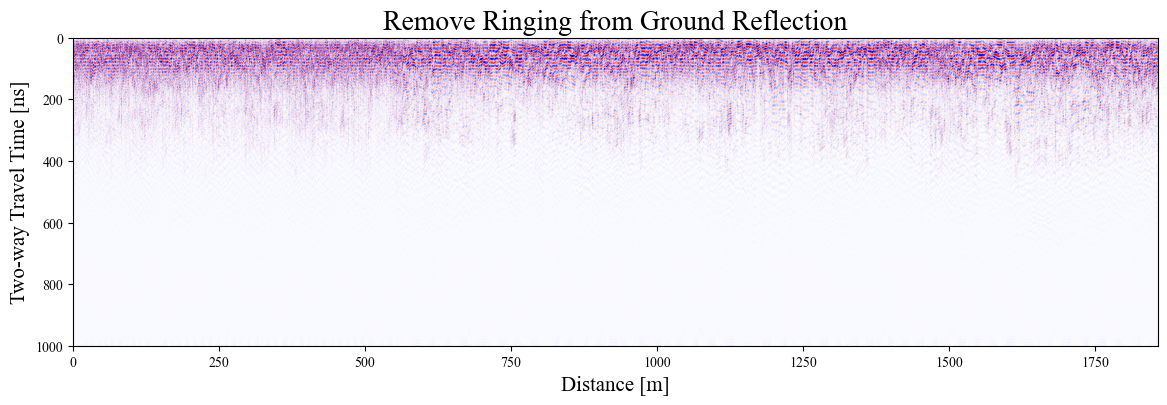

In [101]:
from scipy.fft import fft, ifft, fftfreq    
arr = np.array([bandpass.bandpass_filter(t, dt=((1/px_per_ns)*1e-9), low_f=1.5e7, high_f=9.5e7) for t in arr.T]).T
plt.imshow(arr, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, (1/px_per_ns)*arr.shape[0], 0])
plt.title("Remove Ringing from Ground Reflection")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/bandpass.png', p, cmap='seismic')

## 4.4 Clip the air waves and gain the data

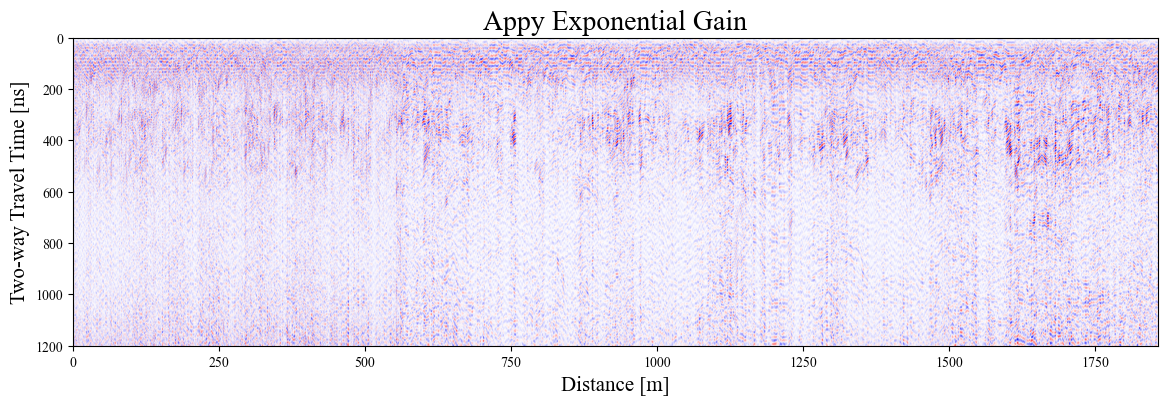

In [197]:
import RoPeR.gain as gain
p = gain.apply_gain(array, 0.018, gain_type='exponential', agc_window=90)
plt.imshow(p, cmap='seismic', aspect='auto', extent = [0, trace_dist_m, observable_depth_ns, 0])
plt.title("Appy Exponential Gain")
plt.xlabel("Distance [m]")
plt.ylabel("Two-way Travel Time [ns]")
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/PreMigration_Processing/gained.png', p, cmap='seismic')

# Neatly align and plot all the data, a "sanity check" figure of the processing done so far

In [25]:
arr = a
n_plots = 6
fig, ax = plt.subplots(n_plots, 1, figsize=(15,10))
step = int(arr.shape[1]/n_plots)
scans = [arr[:, n*step:(n+1)*step] for n in range(0,n_plots)]
trace_dist_iterator = np.array([0, 1, 2, 3, 4, 5, 6])*trace_dist_m/n_plots
print(trace_dist_iterator)

for i in range(0,len(scans)):
    scan = scans[i]
    d = int(trace_dist_iterator[i+1])-int(trace_dist_iterator[i])
    observable_depth = lower_visible-upper_visible
    plot = ax[i].imshow(norm2d(scan), extent=[int(trace_dist_iterator[i]), int(trace_dist_iterator[i+1]), observable_depth, 0], aspect='auto', origin='upper', cmap='seismic')
    if i == len(scans)-1:
        cbar = fig.colorbar(plot, ax=ax.ravel().tolist(), orientation='vertical')
        ax[i].set_xlabel("Distance [m]")
        ax[i].set_ylabel("twt [ns]")
    fig.suptitle("RoPeR GPR (preprocessed, unmigrated)", fontsize=18, y=0.92)
    

NameError: name 'a' is not defined

# 5. Generate a velocity model for the subsurface

We have preprocessed the data and it was so easy! (it wasnt). Now we can finally begin doing what it literally everyone else's first step in GPR processing!

Li et. al. go to 1200ns. I personally have a hard time trusting data at 171m. Even for dry sand and gravel at such low frequency, everyone I've talked to wouldn't expect >100m. Even the IDed dipping reflectors weren't bellow 20m. I think we strike a good balance restricting ourselves to the upper 80m, which, for the absolute lowest eps_r, should be around 800-1000ns.

## 5.1 Zoom where we want to look

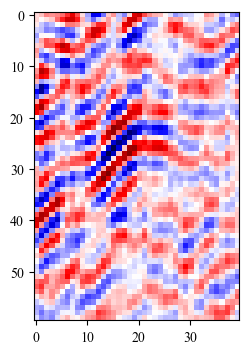

In [78]:
min_x, max_x = 230, 250
min_t, max_t = 300, 450
array, bounds = zoom(p, [min_x, max_x, max_t, min_t])
cmap = plt.get_cmap('seismic')
rgb_img = cmap(array)[:,:,0]
plt.imsave('/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_selection.png', array, cmap='seismic')
fig = plt.figure(figsize=(6,4))
plt.imshow(array, cmap="seismic")
# Dmig, tmig, xmig = mig.fkmig(array, dt=1/(px_per_ns*1e9), dx=0.5, v=3e8/np.sqrt(4), params=None)

# Tlim = 450e-9
# Nt = int(Tlim/((1/px_per_ns)*1e-9))
# t_samples, x_positions = np.arange(200e-9, Tlim, ((1/px_per_ns)*1e-9)), np.arange(230, 250, 0.5)
# m = Kichhoff(array, 4, Tlim, Nt, t_samples, x_positions)
# fig, ax = plt.subplots(1, 3)
# ax[0].imshow(array, cmap="seismic"), ax[1].imshow(Dmig, cmap="seismic"), ax[2].imshow(m.T, cmap="seismic")

## 5.2 Hyperbola fitting, more options
1. manually anotate to get hyperbolae -- This easy and pretty reliable, but I've always said, why do something the easy way when you can spend 2 months learning and coding a worse solution? -->
2. C3!! This is the **preeminent** hyperbola anotating algorithm. Unfortuantely, in most cases, our data is so noisy (in ways that we couldn't remove using standard -- not overkill -- signal processing) that this doesn't work. I'll use a combination of both.

### 5.2.1 User Discretion -- Classic Manual Hyperbola Drawing

In [31]:
import tkinter as tk
import numpy as np
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
import cv2

# px_per_ns = 0.4
# bounds = [0, 150, 1000, 0]

example_image = np.array(cv2.imread('/Users/coltenrodriguez/Desktop/Senior_Thesis/RoPeR_selection.png'))
dx = 0.5
dt = 1/px_per_ns

In [32]:
import tkinter as tk
import numpy as np
from PIL import Image, ImageTk
import matplotlib.pyplot as plt
import cv2
import SimulatingGPR.gprsim as gprsim


hyperbolae = {'coords':[], 'perms':[]}
class ParabolaDrawer:
    def __init__(self, root, image_array, dx, dt, bounds):
        self.root = root
        self.image_array = image_array

        # Normalize image to 8-bit grayscale
        self.img = Image.fromarray(image_array)
        self.tk_img = ImageTk.PhotoImage(self.img)

        self.canvas = tk.Canvas(root, width=self.img.width, height=self.img.height)
        self.canvas.pack()
        self.canvas.create_image(0, 0, anchor='nw', image=self.tk_img)

        self.points = []
        self.canvas.bind("<Button-1>", self.on_click)
        self.x_adj = bounds[0]
        self.t_adj = bounds[3]
        self.dx = dx
        self.dt = dt

    def on_click(self, event):
        x, y = event.x, event.y
        self.points.append((x, y))
        self.canvas.create_oval(x-2, y-2, x+2, y+2, fill='red')

        if len(self.points) == 3:
            self.fit_and_draw_parabola()

    def fit_and_draw_parabola(self):
        x_vals = np.array([p[0] for p in self.points])
        y_vals = np.array([p[1] for p in self.points])
        

        # Fit parabola: y = ax^2 + bx + c
        coeffs = np.polyfit(x_vals, y_vals, 2)  # returns [a, b, c]
        a, b, c = coeffs

        # Generate x values across the canvas
        x_range = np.linspace(0, self.img.width - 1, 500)
        y_range = a * x_range**2 + b * x_range + c

        xs = []
        ys = []
        
        # Draw the parabola
        for i in range(len(x_range) - 1):
            x1, y1 = x_range[i], y_range[i]
            x2, y2 = x_range[i+1], y_range[i+1]

            # Clip y to canvas bounds
            if 0 <= y1 < self.img.height and 0 <= y2 < self.img.height:
                self.canvas.create_line(x1, y1, x2, y2, fill='cyan', width=2)
                ys.append(y1)
                xs.append(x1)

        v, x0, t0 = gprsim.fit_hyperbola(self.image_array, 1, 'robust_fit', dx, dt, (np.array(xs) + self.x_adj) * self.dx, -(np.array(ys) + self.t_adj))
        print((3e8/v)**2, x0, t0*1e9)
        hyperbolae['coords'].append([x_vals, y_vals])
        hyperbolae['perms'].append((3e8/v)**2)
        self.points = []  # Reset for next parabola


# Example usage:
if __name__ == "__main__":
    root = tk.Tk()
    root.title("Parabola Drawer")
    # depth, width, channels = example_image.shape
    depth, width = array.shape
    resized_img = cv2.resize(array, (width*2, depth*2), interpolation=cv2.INTER_AREA)
    app = ParabolaDrawer(root, resized_img, dx, dt, bounds)
    root.mainloop()


# Method 2: Column Connection Clustering

In [ ]:
import SimulatingGPR.gprsim as gprsim
import numpy as np
import matplotlib.pyplot as plt
# Parameters
eps_r = 3                  # relative dielectric permittivity
rf = 40e5                 # radar frequency different from pulse frequency
dt = 1e-9                  # seconds
dx = 1                     # meters
region_shape = (70, 1e-6)  # grid (x,z)
SNR = 0.1
wavetype = 'gaussian'

# Point reflectors at (x,t) where x [m] and t [s]
reflectors = [(25, 100e-9), (45, 200e-9)]
long_reflectors = [gprsim.dipping_reflector((0, 50e-9), (40, 50e-9)), gprsim.dipping_reflector((41, 50e-9), (69, 120e-9))]

data, x_positions, t_samples = gprsim.gprsim(eps_r, rf, dt, dx, reflectors, region_shape, wavetype, SNR, long_reflectors)
data = array
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 10,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.subplot.wspace': 0,  # Example: Increase horizontal spacing
    'figure.subplot.hspace': 0.4,  # Example: Increase vertical spacing
    'figure.figsize': (6, 6) # Adjust figure size
})
plt.imshow(data, aspect='auto', cmap='seismic')
plt.xlabel("Antenna position (m)")
plt.show()

## Thresholding

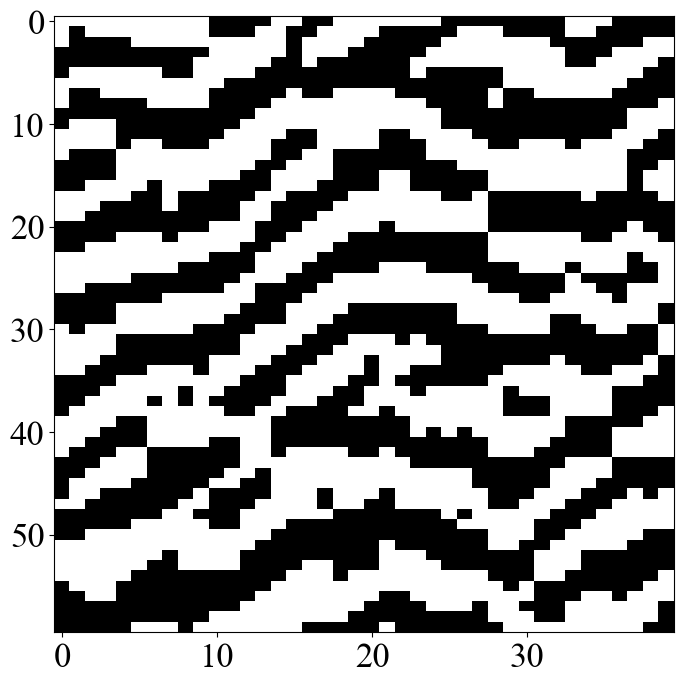

In [33]:
data=array
threshold = np.mean(data[np.where(data>data.min()*0.9)])
data_binary = np.zeros_like(data)
data_binary[np.where(data>threshold)] = 1
plt.rcParams.update({
    'font.family': 'serif',  # Often a default in MATLAB
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'lines.linewidth': 1.5,
    'lines.marker': 'o',  # Example marker, adjust as needed
    'grid.color': 'lightgray',
    'grid.linestyle': ':',
    'grid.linewidth': 0.5,
    'axes.grid': False,
    'figure.figsize': (8, 6) # Adjust figure size
})
fig = plt.figure(figsize=(8,8))
plt.imshow(-data_binary, cmap='binary', aspect='auto')

## Cluster the thresholded data

In [34]:
def get_column_segments(binary_col, s):
    """
    binary_col: 1D array (rows) of 0/1 values
    returns: list of sets of row indices
    """
    segments = []
    current = []

    for r, val in enumerate(binary_col):
        if val:
            current.append(r)
        else:
            if len(current) >= s:
                segments.append(set(current))
            current = []

    if len(current) >= s:
        segments.append(set(current))

    return segments


In [35]:
def c3_clustering(binary_img, s):
    """
    binary_img: 2D numpy array (rows x cols), values {0,1}
    returns: list of clusters, each cluster is a list of (row, col)
    """

    rows, cols = binary_img.shape
    clusters = []              # list of clusters (each is list of pixels)
    prev_segments = []         # segments from previous column
    prev_cluster_ids = []      # which cluster each prev segment belongs to

    for col in range(cols):
        col_segments = get_column_segments(binary_img[:, col], s)
        num_c = len(col_segments)

        if col == 0:
            # Initialize clusters
            for seg in col_segments:
                cluster = [(r, col) for r in seg]
                clusters.append(cluster)
                prev_cluster_ids.append(len(clusters) - 1)
            prev_segments = col_segments
            continue

        new_prev_segments = []
        new_prev_cluster_ids = []

        for j, seg_c in enumerate(col_segments):
            attached = False

            for k, seg_p in enumerate(prev_segments):
                n = len(seg_c & seg_p)  # number of connecting elements

                if n >= s:
                    if not attached:
                        # extend existing cluster
                        cid = prev_cluster_ids[k]
                        clusters[cid].extend((r, col) for r in seg_c)
                        new_prev_segments.append(seg_c)
                        new_prev_cluster_ids.append(cid)
                        attached = True
                    else:
                        # branching: clone cluster
                        new_cluster = clusters[prev_cluster_ids[k]].copy()
                        new_cluster.extend((r, col) for r in seg_c)
                        clusters.append(new_cluster)
                        new_prev_segments.append(seg_c)
                        new_prev_cluster_ids.append(len(clusters) - 1)

            if not attached:
                # start new cluster
                new_cluster = [(r, col) for r in seg_c]
                clusters.append(new_cluster)
                new_prev_segments.append(seg_c)
                new_prev_cluster_ids.append(len(clusters) - 1)

        prev_segments = new_prev_segments
        prev_cluster_ids = new_prev_cluster_ids

    return clusters

clusters = c3_clustering(data_binary, s=2)

In [36]:
print(len(clusters))

113


## Show the clusters

In [37]:
import numpy as np

def clusters_to_rgb(shape, clusters, seed=0, background=(0, 0, 0)):
    """
    Create an RGB image where each cluster has its own color.

    Parameters
    ----------
    shape : tuple
        (H, W)
    clusters : list
        list of clusters, each cluster is iterable of (row, col)
    seed : int
        seed for reproducible colors
    background : tuple
        RGB background color (0-255)

    Returns
    -------
    rgb : np.ndarray
        (H, W, 3) uint8 RGB image
    """
    H, W = shape
    rgb = np.zeros((H, W, 3), dtype=np.uint8)
    rgb[:] = background

    rng = np.random.default_rng(seed)
    colors = (rng.integers(0, 256, size=(len(clusters), 3))).astype(np.uint8)

    for k, cluster in enumerate(clusters):
        if cluster is None or len(cluster) == 0:
            continue
        pts = np.asarray(cluster, dtype=int)
        r, c = pts[:, 0], pts[:, 1]

        mask = (r >= 0) & (r < H) & (c >= 0) & (c < W)
        r, c = r[mask], c[mask]

        rgb[r, c] = colors[k]

    return rgb


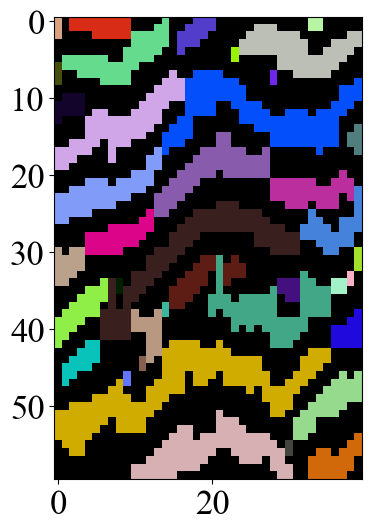

In [38]:
plt.imshow(clusters_to_rgb(np.zeros_like(data_binary).shape, clusters[0:], seed=0, background=(0, 0, 0)))

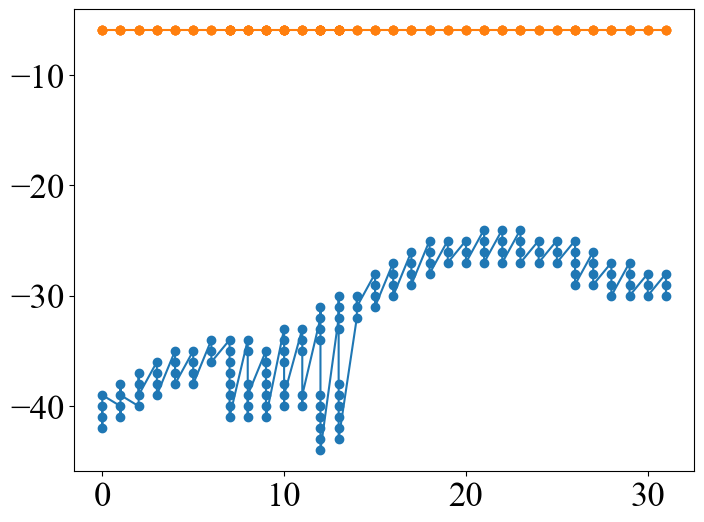

In [39]:
v, x0, t0 = gprsim.fit_hyperbola(data, num_hyperbolas=1, method='robust_fit', dx=0.5, dt=(1/px_per_ns), x=np.array([pix[0] for pix in clusters[6]]), t=np.array([pix[1] for pix in clusters[6]]))

v, x0, t0 = v*1e9*2, x0, (t0*2)/1e-9

plt.plot(np.array([pix[1] for pix in clusters[6]]), -np.array([pix[0] for pix in clusters[6]]))
plt.plot(np.array([pix[1] for pix in clusters[6]]), -np.sqrt(t0**2 + (np.abs(np.array([pix[1] for pix in clusters[6]])-x0)/v)**2))


# 5 Migration with three methods

## Try a different method, FT each trace and bound the sprectral density curve 

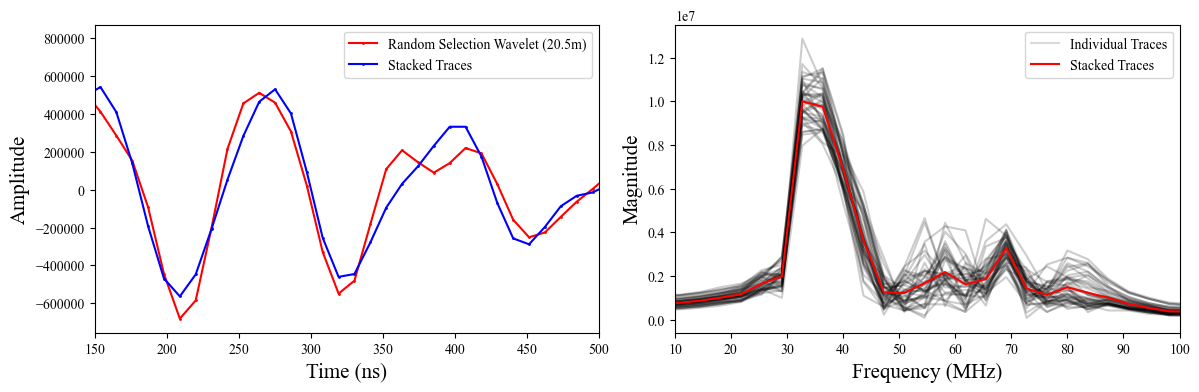

In [26]:
fig, axs = plt.subplots(1, 2)
fig.subplots_adjust(wspace=0.15)

phase_offset = phase_offset
'''
time-space
'''
axs[0].set_ylabel('Amplitude'), axs[0].set_xlabel('Time (ns)'), axs[0].set_xlim(150, 500)
random_wavelet = phase_offset[:, 41]
stacked_wavelet = np.mean(phase_offset, axis=1)
axs[0].plot(np.linspace(0,1200, phase_offset.shape[0]), random_wavelet, label='Random Selection Wavelet (20.5m)', c='red', markersize=1)
axs[0].plot(np.linspace(0,1200, phase_offset.shape[0]), stacked_wavelet, label='Stacked Traces', c='blue', markersize=1)
axs[0].legend()


'''
Frequency Space. Taking the FT of each trace and averaging them
'''
freq_space_im = []
for i, trace in enumerate(phase_offset.T[::130]):
    x = np.array(trace)       # your 1D waveform
    n = len(x)
    
    # Sampling interval (seconds)
    dt = 2.5e-9           # 2.5 ns
    
    # FFT
    X = np.fft.fft(x)
    
    # Frequency axis
    freq = np.fft.fftfreq(n, d=dt)

    # Magnitude spectrum
    magnitude = np.abs(X)
    freq_space_im.append(magnitude)
    
    pos_mask = freq >= 0
    axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.2, markersize=0)

    

magnitude = np.array(freq_space_im).T.mean(axis=1)
pos_mask = freq >= 0
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.15, markersize=0, label='Individual Traces')
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='red', markersize=0, label='Stacked Traces'), axs[1].set_xlim(10, 100)
axs[1].set_xlabel('Frequency (MHz)'), axs[1].set_ylabel('Magnitude')
axs[1].legend()

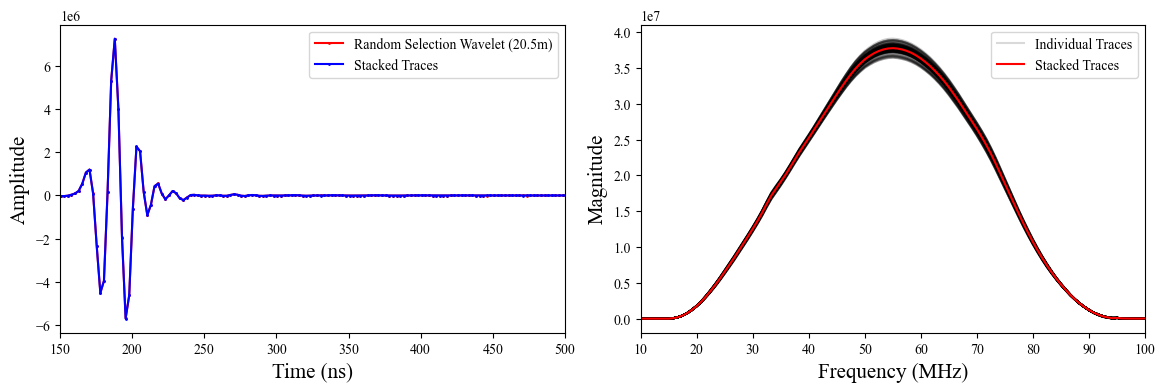

In [16]:
fig, axs = plt.subplots(1, 2)
fig.subplots_adjust(wspace=0.15)
'''
time-space
'''
axs[0].set_ylabel('Amplitude'), axs[0].set_xlabel('Time (ns)'), axs[0].set_xlim(150, 500)
random_wavelet = self_detections[:, 20]
stacked_wavelet = np.mean(self_detections, axis=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), random_wavelet, label='Random Selection Wavelet (20.5m)', c='red', markersize=1)
axs[0].plot(np.linspace(0,1200, self_detections.shape[0]), stacked_wavelet, label='Stacked Traces', c='blue', markersize=1)
axs[0].legend()


'''
Frequency Space. Taking the FT of each trace and averaging them
'''
freq_space_im = []
for i, trace in enumerate(self_detections.T):
    x = np.array(trace)       # your 1D waveform
    n = len(x)
    
    # Sampling interval (seconds)
    dt = 2.5e-9           # 2.5 ns
    
    # FFT
    X = np.fft.fft(x)
    
    # Frequency axis
    freq = np.fft.fftfreq(n, d=dt)

    # Magnitude spectrum
    magnitude = np.abs(X)
    freq_space_im.append(magnitude)
    
    pos_mask = freq >= 0
    axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.2, markersize=0)

    

magnitude = np.array(freq_space_im).T.mean(axis=1)
pos_mask = freq >= 0
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='black', alpha=0.15, markersize=0, label='Individual Traces')
axs[1].plot(freq[pos_mask] * 1e-6, magnitude[pos_mask], color='red', markersize=0, label='Stacked Traces'), axs[1].set_xlim(10, 100)
axs[1].set_xlabel('Frequency (MHz)'), axs[1].set_ylabel('Magnitude')
axs[1].legend()

(<matplotlib.image.AxesImage at 0x15251db10>, Text(0.5, 1.0, 'RTM'))

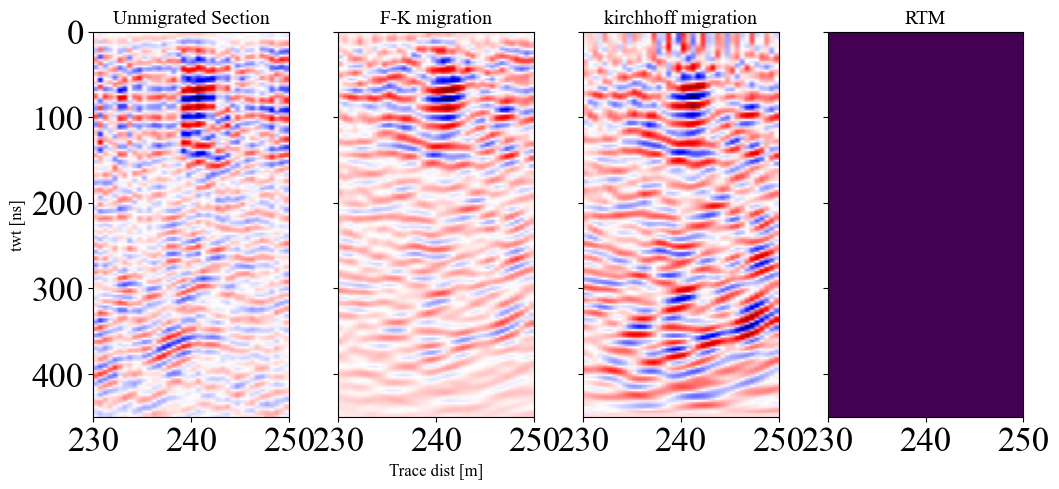

In [54]:
fig, axs = plt.subplots(1, 4, figsize=(12,5), sharey=True)
fig.subplots_adjust(wspace=0.25)

data=array
axs[0].imshow(data, aspect='auto', cmap='seismic', extent=[min_x, max_x, max_t, min_t]), axs[0].set_title('Unmigrated Section'), axs[0].set_ylabel('twt [ns]')

Dmig, tmig, xmig = mig.fkmig(array, dt=1/(px_per_ns*1e9), dx=0.5, v=3e8/np.sqrt(4), params=None)
axs[1].imshow(Dmig, aspect='auto', cmap='seismic', extent=[min_x, max_x, max_t, min_t]), axs[1].set_title('F-K migration'), axs[1].set_xlabel('Trace dist [m]')

Tlim = 450e-9
Nt = int(Tlim/((1/px_per_ns)*1e-9))
t_samples, x_positions = np.arange(0, Tlim, ((1/px_per_ns)*1e-9)), np.arange(230, 250, 0.5)
m = Kichhoff(data, 4, Tlim, Nt, t_samples, x_positions)
axs[2].imshow(m.T, aspect='auto', cmap='seismic', extent=[min_x, max_x, max_t, min_t]), axs[2].set_title('kirchhoff migration')

axs[3].imshow(np.zeros_like(data), aspect='auto', extent=[min_x, max_x, max_t, min_t]), axs[3].set_title('RTM')

In [144]:
c = 0.14
I = 10/3.3e8
np.log(-0.5/((I)/(I-1) - 0.5*(I)/(I-1)))/c

123.657272065198